In [1]:
import os
os.environ.setdefault("DLOMIX_BACKEND", "torch")
from dlomix.models.prosit_torch import PrositIntensityUncertaintyPredictor, PrositIntensityPredictor
from dlomix.data import FragmentIonIntensityDataset
from dlomix.losses.intensity_torch import gaussian_nll, masked_spectral_distance
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import torch

Using PyTorch Backend for DLOmix. To change the backend, set the DLOMIX_BACKEND environment variable to tensorflow or pytorch and re-import DLOmix.


/home/caswiv/miniconda3/envs/BB200X/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Available feature extractors are (use the key of the following dict and pass it to features_to_extract in the Dataset Class):
{
   "atom_count": "Atom count of PTM.",
   "delta_mass": "Delta mass of PTM.",
   "mod_gain": "Gain of atoms due to PTM.",
   "mod_loss": "Loss of atoms due to PTM.",
   "red_smiles": "Reduced SMILES representation of PTM."
}.
When writing your own feature extractor, you can either
    (1) use the FeatureExtractor class or
    (2) write a function that can be mapped to the Hugging Face dataset.
In both cases, you can access the parsed sequence information from the dataset using the following keys, which all provide python lists:
    - _parsed_sequence: parsed sequence
    - _n_term_mods: N-terminal modifications
    - _c_term_mods: C-terminal modifications



## Loading Data

In [2]:
residue_masses = {
    "G":57.02146, "A":71.03711, "S":87.03203,
    "P":97.05276, "V":99.06841, "T":101.04768,
    "C":103.00919, "L":113.08406, "I":113.08406,
    "N":114.04293, "D":115.02694, "Q":128.05858,
    "K":128.09496, "E":129.04259, "M":131.04049,
    "H":137.05891, "F":147.06841, "R":156.10111,
    "Y":163.06333, "W":186.07931,
    "Water":18.010565, "Proton":1.007276
}

y_ion_mz_label =[
    "y1 +1", "y1 +2", "y1 +3", "y2 +1", "y2 +2", "y2 +3", 
    "y3 +1", "y3 +2", "y3 +3", "y4 +1", "y4 +2", "y4 +3", 
    "y5 +1", "y5 +2", "y5 +3", "y6 +1", "y6 +2", "y6 +3", 
    "y7 +1", "y7 +2", "y7 +3", "y8 +1", "y8 +2", "y8 +3", 
    "y9 +1", "y9 +2", "y9 +3", "y10 +1", "y10 +2", "y10 +3",   
    "y11 +1", "y11 +2", "y11 +3", "y12 +1", "y12 +2", "y12 +3",   
    "y13 +1", "y13 +2", "y13 +3", "y14 +1", "y14 +2", "y14 +3",   
    "y15 +1", "y15 +2", "y15 +3", "y16 +1", "y16 +2", "y16 +3",   
    "y17 +1", "y17 +2", "y17 +3", "y18 +1", "y18 +2", "y18 +3",   
    "y19 +1", "y19 +2", "y19 +3", "y20 +1", "y20 +2", "y20 +3",   
    "y21 +1", "y21 +2", "y21 +3", "y22 +1", "y22 +2", "y22 +3",   
    "y23 +1", "y23 +2", "y23 +3", "y24 +1", "y24 +2", "y24 +3",   
    "y25 +1", "y25 +2", "y25 +3", "y26 +1", "y26 +2", "y26 +3",   
    "y27 +1", "y27 +2", "y27 +3", "y28 +1", "y28 +2", "y28 +3",   
    "y29 +1", "y29 +2", "y29 +3", "y30 +1", "y30 +2", "y30 +3",   
]

b_ion_mz_label = [
    "b1 +1", "b1 +2", "b1 +3", "b2 +1", "b2 +2", "b2 +3",
    "b3 +1", "b3 +2", "b3 +3", "b4 +1", "b4 +2", "b4 +3",
    "b5 +1", "b5 +2", "b5 +3", "b6 +1", "b6 +2", "b6 +3",
    "b7 +1", "b7 +2", "b7 +3", "b8 +1", "b8 +2", "b8 +3",
    "b9 +1", "b9 +2", "b9 +3", "b10 +1", "b10 +2", "b10 +3",
    "b11 +1", "b11 +2", "b11 +3", "b12 +1", "b12 +2", "b12 +3",
    "b13 +1", "b13 +2", "b13 +3", "b14 +1", "b14 +2", "b14 +3",
    "b15 +1", "b15 +2", "b15 +3", "b16 +1", "b16 +2", "b16 +3",
    "b17 +1", "b17 +2", "b17 +3", "b18 +1", "b18 +2", "b18 +3",
    "b19 +1", "b19 +2", "b19 +3", "b20 +1", "b20 +2", "b20 +3",
    "b21 +1", "b21 +2", "b21 +3", "b22 +1", "b22 +2", "b22 +3",
    "b23 +1", "b23 +2", "b23 +3", "b24 +1", "b24 +2", "b24 +3",
    "b25 +1", "b25 +2", "b25 +3", "b26 +1", "b26 +2", "b26 +3",
    "b27 +1", "b27 +2", "b27 +3", "b28 +1", "b28 +2", "b28 +3",
    "b29 +1", "b29 +2", "b29 +3", "b30 +1", "b30 +2", "b30 +3",
]

alphabet = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 
    'F': 5, 'G': 6, 'H': 7, 'I': 8, 
    'K': 9, 'L': 10, 'M': 11, 'N': 12, 
    'P': 13, 'Q': 14, 'R': 15, 'S': 16, 
    'T': 17, 'V': 18, 'W': 19, 'Y': 20,
    }

In [3]:
def fragment_ions(sequence:str, verbose=False):
    '''
    Returns the b-, and y-ion masses of the given sequence,\n
    verbose will print results after each step.
    '''
    masses = np.array([residue_masses[aa] for aa in sequence])
    flip_masses = np.flip(masses)
    b_cumsum = np.cumsum(masses[:-1])
    y_cumsum = np.cumsum(flip_masses[:-1])
    
    b_ions_masses = b_cumsum + residue_masses["Proton"]
    b_ions_labels = np.array([(f'B{n}: ' + sequence[:n]) for n in range(1, len(sequence))])
    
    y_ions_masses = y_cumsum + (residue_masses["Proton"] + residue_masses["Water"])
    y_ions_labels = np.flip(np.array([(f'Y{len(sequence)-n}: ' + sequence[n:]) for n in range(1, len(sequence))]))

    if verbose:
        print(f"Residue masses: {masses}")
        print(f"b-ion only aa masses: {b_cumsum}")
        print(f"y-ion only aa masses: {y_cumsum}\n")
        print(f"b-ion sequences: {b_ions_labels}")
        print(f"b-ion masses: {b_ions_masses}\n")
        print(f"y-ion sequences: {y_ions_labels}")
        print(f"y-ion masses: {y_ions_masses}")
        
    return b_ions_masses, b_ions_labels, y_ions_masses, y_ions_labels

def mz(b_ions, y_ions, n_charge, verbose=False):
    '''
    Creates a number_of_charges x number_of_ions numpy array of m/z values,\n
    verbose will print the numpy arrays, rows start from +1 and goes to n_charge
    '''
    b_mz = np.zeros(shape=(n_charge, len(b_ions)))
    y_mz = np.zeros(shape=(n_charge, len(y_ions)))
    
    for c in range(1, n_charge+1):
        b_mass_charge = b_ions / c
        y_mass_charge = y_ions / c
        b_mz[c-1] = b_mass_charge
        y_mz[c-1] = y_mass_charge
    if verbose:
        print(b_mz)
        print(y_mz)
    return b_mz, y_mz

def encode_sequence(sequence, seq_length):
    encoding = [21,] # N-terminal
    for aa in sequence:
        encoding.append(alphabet[aa])
    encoding.append(22) # C-terminal
    #padding
    diff = seq_length - len(sequence)
    for n in range(0, diff):
        encoding.append(0)
    print(f"Encoding: {encoding}\nLength: {len(encoding)}")
    return encoding

In [4]:
# Example peptide (should be fetched from test set)
sequence = "TRLQAENSELSR"

encoded_sequence = [encode_sequence(sequence, 30)]
intensity_raw = [[ 0.1000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.3400,  0.0000,
         0.0000,  0.1300,  0.0000,  0.0000,  1.0000,  0.0200,  0.0000,  0.0900,
         0.0000,  0.0000,  0.5500,  0.0000,  0.0000,  0.6300,  0.1500,  0.0000,
         0.7400,  0.0900,  0.0000,  0.7800,  0.1600,  0.0000,  0.9000,  0.0500,
         0.0000,  0.6500,  0.1500,  0.0000,  0.1000,  0.0100,  0.0000,  0.2600,
         0.0600,  0.0000,  0.0500,  0.0000,  0.0000,  0.0800,  0.1600,  0.0000,
         0.0000,  0.0000,  0.0200,  0.0500,  0.0100,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000]]
collision_energy_normed = [0.2556]
precursor_charge_onehot = [[0., 0., 1., 0., 0., 0.]] # +3
mod_loss = [[[1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.]]]
delta_mass = [[[0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.]]]

test_data = {
    'modified_sequence': torch.tensor(encoded_sequence),
    #'intensities_raw': torch.tensor(intensity_raw),
    'collision_energy_aligned_normed': torch.tensor(collision_energy_normed),
    'precursor_charge_onehot': torch.tensor(precursor_charge_onehot),
    'mod_loss': torch.tensor(mod_loss),
    'delta_mass': torch.tensor(delta_mass),
}

b_ion_mass, b_labl, y_ion_mass, y_labl = fragment_ions(sequence)
b_mz, y_mz = mz(b_ion_mass, y_ion_mass, 3)

Encoding: [21, 17, 15, 10, 14, 1, 4, 12, 16, 4, 10, 16, 15, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32


In [5]:
# Uncomment if you want to run a quick local training (an imported trained model is more useful)

## Getting dataset
#TRAIN_DATAPATH = "../../example_dataset/intensity/third_pool_processed_sample.parquet" # RELATIVE PATH needs to be changed should the file move location
#
#d = FragmentIonIntensityDataset(
#    data_source=TRAIN_DATAPATH,
#    #data_source=TRAIN_DATAPATH,
#    #val_data_source=VAL_DATAPATH,
#    #test_data_source=TEST_DATAPATH,
#    max_seq_len=32,
#    batch_size=8,
#    val_ratio=0.2,
#    model_features=["collision_energy_aligned_normed", "precursor_charge_onehot"],
#    sequence_column="modified_sequence",
#    label_column="intensities_raw",
#    features_to_extract=["mod_loss", "delta_mass"],
#    dataset_type="pt",
#    with_termini=True,
#    encoding_scheme="naive-mods", # Was missing in original code, setting encoding scheme to naive-mods is what allows modifications to exist (default is Un-modified (UNMOD))
#)

## Uncertainty Aware Training and Data Formatting

In [6]:
sequence_length = 32
model = PrositIntensityUncertaintyPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
loss_criterion = gaussian_nll

In [7]:
# Uncomment if you want to run a quick local training (an imported trained model is more useful)

# UPDATE FOR MEAN BEING IN LOG SPACE

#for epoch in tqdm(range(0, 20)):
#    epoch_loss = 0
#    mae = 0
#    v_mae = 0
#    model.train()
#    data_size = len(d.tensor_train_data)
#    for batch in d.tensor_train_data:
#        optimizer.zero_grad()
#
#        output_mean, output_var, output_presence = model(batch)
#        loss = loss_criterion(batch["intensities_raw"], output_mean, output_var, output_presence, batch["modified_sequence"])
#        
#        # print(loss.item())
#        y_true = batch["intensities_raw"].detach()
#        present = y_true > 0
#        y_true[~present] = 0
#        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()
#
#        epoch_loss += loss.item()
#
#        loss.backward()
#
#        # Add before optimizer.step()
#        torch.nn.utils.clip_grad_norm_(
#            model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
#        )
#        optimizer.step()
#    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
#    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")
#
#    model.eval()
#    val_loss_total = 0.0
#    with torch.no_grad():
#        val_data_size = len(d.tensor_val_data)
#        for batch in d.tensor_val_data:
#            
#            val_mean, val_var, val_missing = model(batch)
#            val_loss = loss_criterion(batch["intensities_raw"], val_mean, val_var, val_missing, batch["modified_sequence"])
#            val_loss_total += val_loss.item()
#
#            y_true = batch["intensities_raw"].detach()
#            present = y_true > 0
#            y_true[~present] = 0
#            v_mae += torch.mean(torch.abs(torch.sub(val_mean, y_true))).item()
#
#        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
#        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")


In [8]:
# If loading from a checkpoint
checkpoint = torch.load(
    "/home/caswiv/GitRepos/dlomix-uncertainty-aware/notebooks/uncertainty_aware_plotting_examples/UA_checkpoint_epoch_120.pth", # Change to relevant file
        weights_only=True,
        map_location=torch.device('cpu'),
)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']

In [9]:
model.eval()
log_mean, log_var, presence = model(test_data)

#  Data formatting before plotting
np_mean = torch.exp(log_mean.detach().float())
np_mean = np_mean.cpu().numpy().flatten() 

np_var = torch.exp(log_var.detach().float())
np_var = np_var.cpu().numpy().flatten() # Numpy turns positive small tensor values negative

np_presence = torch.sigmoid(presence.detach()).numpy().flatten()

np_true = torch.tensor(intensity_raw).detach()
present = np_true > 0
np_true[~present] = 0
np_true = np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
np_mean = np_mean[:possible_indx]
np_var = np_var[:possible_indx]
np_presence = np_presence[:possible_indx]
np_true = np_true[:possible_indx]

# Shorten all variances that would go beyond 0 in the plot
np_var_lower = np_var
for e in range(0, len(np_mean)-1):
    if np_mean[e] < np_var_lower[e]:
        np_var_lower[e] = np_mean[e]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_ions_mean = np_mean[::6]
y2_ions_mean = np_mean[1::6]
y3_ions_mean = np_mean[2::6]
b1_ions_mean = np_mean[3::6]
b2_ions_mean = np_mean[4::6]
b3_ions_mean = np_mean[5::6]

y1_ions_var = np_var[::6]
y2_ions_var = np_var[1::6]
y3_ions_var = np_var[2::6]
b1_ions_var = np_var[3::6]
b2_ions_var = np_var[4::6]
b3_ions_var = np_var[5::6]

print(b1_ions_var)

y1_ions_var_lower = np_var_lower[::6]
y2_ions_var_lower = np_var_lower[1::6]
y3_ions_var_lower = np_var_lower[2::6]
b1_ions_var_lower = np_var_lower[3::6]
b2_ions_var_lower = np_var_lower[4::6]
b3_ions_var_lower = np_var_lower[5::6]

print(b1_ions_var_lower)

y1_ions_presence = np_presence[::6]
y2_ions_presence = np_presence[1::6]
y3_ions_presence = np_presence[2::6]
b1_ions_presence = np_presence[3::6]
b2_ions_presence = np_presence[4::6]
b3_ions_presence = np_presence[5::6]

y1_ions_true = np_true[::6]
y2_ions_true = np_true[1::6]
y3_ions_true = np_true[2::6]
b1_ions_true = np_true[3::6]
b2_ions_true = np_true[4::6]
b3_ions_true = np_true[5::6]

# Create vector with all y ions and one with all b ions
# y_ions_mean = np.array([y_p1_mean, y_p2_mean, y_p3_mean]).flatten()
# y_ions_var = np.array([y_p1_var, y_p2_var, y_p3_var]).flatten()
# y_ions_presence = np.array([y_p1_presence, y_p2_presence, y_p3_presence]).flatten()

# b_ions_mean = np.array([b_p1_mean, b_p2_mean, b_p3_mean]).flatten()
# b_ions_var = np.array([b_p1_var, b_p2_var, b_p3_var]).flatten()
# b_ions_presence = np.array([b_p1_presence, b_p2_presence, b_p3_presence]).flatten()

# Get labels for peaks (full ion sequences are in b_labl and y_labl)
y1_point_labl = y_ion_mz_label[:(3*(len(sequence)-1)):3]
y2_point_labl = y_ion_mz_label[1:(3*(len(sequence)-1)):3]
y3_point_labl = y_ion_mz_label[2:(3*(len(sequence)-1)):3]

b1_point_labl = b_ion_mz_label[:(3*(len(sequence)-1)):3]
b2_point_labl = b_ion_mz_label[1:(3*(len(sequence)-1)):3]
b3_point_labl = b_ion_mz_label[2:(3*(len(sequence)-1)):3]

# Will now have the same order as the mean, var, and presence arrays
# y_point_labl = np.array([y1_point_labl, y2_point_labl, y3_point_labl]).flatten()
# b_point_labl = np.array([b1_point_labl, b2_point_labl, b3_point_labl]).flatten()

# Get the mz values for each ion type (x-axis), will be same structure as arrays created above
y1_mz = y_mz[0]
y2_mz = y_mz[1]
y3_mz = y_mz[2]

b1_mz = b_mz[0]
b2_mz = b_mz[1]
b3_mz = b_mz[2]

Possible states: 66
[0.01427772 0.08753804 0.11069477 0.08167762 0.06115597 0.06419741
 0.0994693  0.05329831 0.03133416 0.01048338 0.01193915]
[0.01427772 0.08753804 0.11069477 0.08167762 0.06115597 0.06419741
 0.0994693  0.05329831 0.03133416 0.01048338 0.01193915]


In [10]:
print(b1_mz)
print(b1_ions_true)

[ 102.054956  258.156066  371.240126  499.298706  570.335816  699.378406
  813.421336  900.453366 1029.495956 1142.580016 1229.612046]
[0.   0.13 0.09 0.63 0.78 0.65 0.26 0.08 0.05 0.   0.  ]


## Masked Spectral Distance Training and formating

In [11]:
sequence_length = 32
MSD_model = PrositIntensityPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

MSD_optimizer = torch.optim.Adam(params=MSD_model.parameters(), lr=0.0001)
MSD_loss_criterion = masked_spectral_distance

In [12]:
# Uncomment if you want to run a quick local training (an imported trained model is more useful)

# Run if local training is wanted

#for epoch in tqdm(range(0, 20)):
#    epoch_loss = 0
#    mae = 0
#    v_mae = 0
#    MSD_model.train()
#    data_size = len(d.tensor_train_data)
#    for batch in d.tensor_train_data:
#        optimizer.zero_grad()
#
#        output = MSD_model(batch)
#        loss = MSD_loss_criterion(batch["intensities_raw"], output)
#        
#        # print(loss.item())
#        y_true = batch["intensities_raw"].detach()
#        present = y_true > 0
#        y_true[~present] = 0
#        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()
#
#        epoch_loss += loss.item()
#
#        loss.backward()
#
#        # Add before optimizer.step()
#        torch.nn.utils.clip_grad_norm_(
#            MSD_model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
#        )
#        optimizer.step()
#    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
#    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")
#
#    MSD_model.eval()
#    val_loss_total = 0.0
#    with torch.no_grad():
#        val_data_size = len(d.tensor_val_data)
#        for batch in d.tensor_val_data:
#            
#            val = MSD_model(batch)
#            val_loss = MSD_loss_criterion(batch["intensities_raw"], val)
#            val_loss_total += val_loss.item()
#
#            y_true = batch["intensities_raw"].detach()
#            present = y_true > 0
#            y_true[~present] = 0
#            v_mae += torch.mean(torch.abs(torch.sub(val, y_true))).item()
#
#        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
#        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")

In [13]:
# If loading from a checkpoint
MSD_checkpoint = torch.load(
    "/home/caswiv/GitRepos/dlomix-uncertainty-aware/notebooks/uncertainty_aware_plotting_examples/MSD_checkpoint_epoch_120.pth", # Change to relevant file
        weights_only=True,
        map_location=torch.device('cpu'),
)
MSD_model.load_state_dict(MSD_checkpoint['model_state_dict'])
MSD_optimizer.load_state_dict(MSD_checkpoint['optimizer_state_dict'])
MSD_epoch = MSD_checkpoint['epoch']

In [14]:
MSD_model.eval()
MSD_mean = MSD_model(test_data)

# Data formatting before plotting
MSD_np_mean = MSD_mean.detach()
negative = MSD_np_mean < 0
MSD_np_mean[negative] = 0
MSD_np_mean = MSD_np_mean.cpu().numpy().flatten() 

MSD_np_true = torch.tensor(intensity_raw).detach()
present = MSD_np_true > 0
MSD_np_true[~present] = 0
MSD_np_true = MSD_np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
MSD_np_mean = MSD_np_mean[:possible_indx]
MSD_np_true = MSD_np_true[:possible_indx]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_MSD_ions_mean = MSD_np_mean[::6]
y2_MSD_ions_mean = MSD_np_mean[1::6]
y3_MSD_ions_mean = MSD_np_mean[2::6]
b1_MSD_ions_mean = MSD_np_mean[3::6]
b2_MSD_ions_mean = MSD_np_mean[4::6]
b3_MSD_ions_mean = MSD_np_mean[5::6]

y1_MSD_ions_true = MSD_np_true[::6]
y2_MSD_ions_true = MSD_np_true[1::6]
y3_MSD_ions_true = MSD_np_true[2::6]
b1_MSD_ions_true = MSD_np_true[3::6]
b2_MSD_ions_true = MSD_np_true[4::6]
b3_MSD_ions_true = MSD_np_true[5::6]

print(b1_MSD_ions_mean)

Possible states: 66
[0.         0.04965714 0.04711189 0.30472097 0.30859846 0.20939216
 0.07785627 0.03081831 0.02212351 0.         0.        ]


## Plotting

### True Intensities

/tmp/ipykernel_7780/2488780738.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


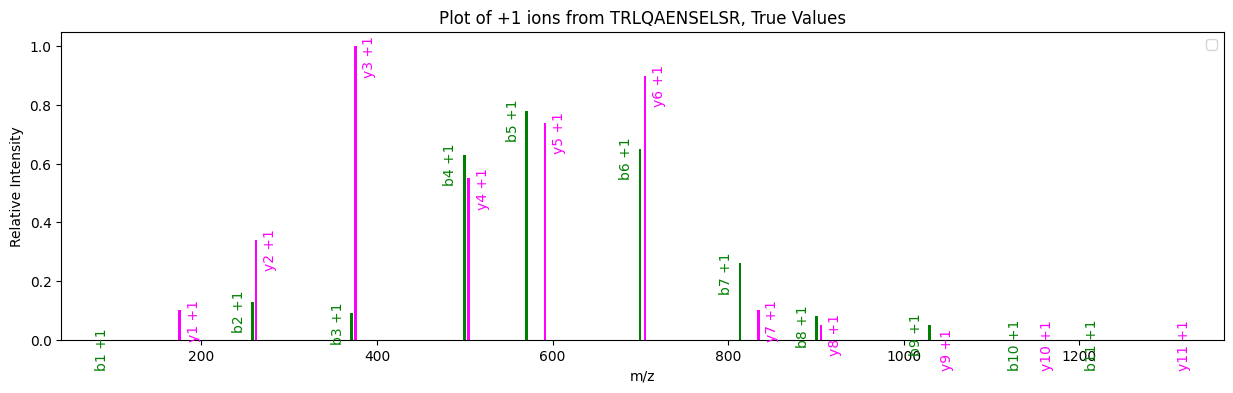

In [15]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, True Values')

plt.bar(b1_mz, b1_ions_true, width=3, color='g')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='magenta')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.legend()

### Uncertainty Aware Model With Labels

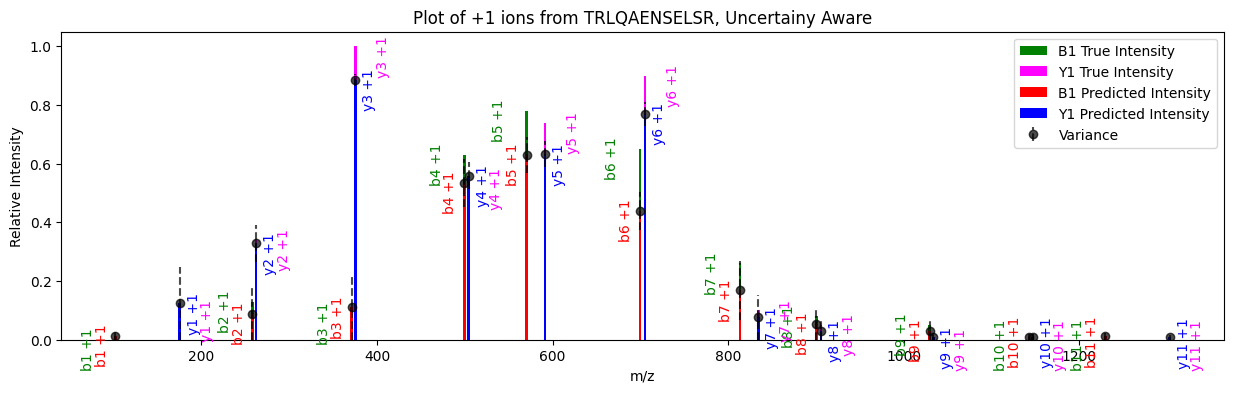

In [16]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Uncertainy Aware')

plt.bar(b1_mz, b1_ions_true, width=3, color='g', label='B1 True Intensity')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-25, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='magenta', label='Y1 True Intensity')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.bar(b1_mz, b1_ions_mean, width=3, color='r', label='B1 Predicted Intensity')
eb_b = plt.errorbar(b1_mz, b1_ions_mean, yerr=[b1_ions_var_lower, b1_ions_var], color='black', fmt='o', alpha=0.7)
eb_b[-1][0].set_linestyle('--')
for xi, yi, text, in zip(b1_mz, b1_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
eb_y = plt.errorbar(y1_mz, y1_ions_mean, yerr=[y1_ions_var_lower, y1_ions_var], color='black', fmt='o', alpha=0.7, label='Variance')
eb_y[-1][0].set_linestyle('--')
for xi, yi, text, in zip(y1_mz, y1_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()

### Uncertainty Aware Model With Presence Prediction

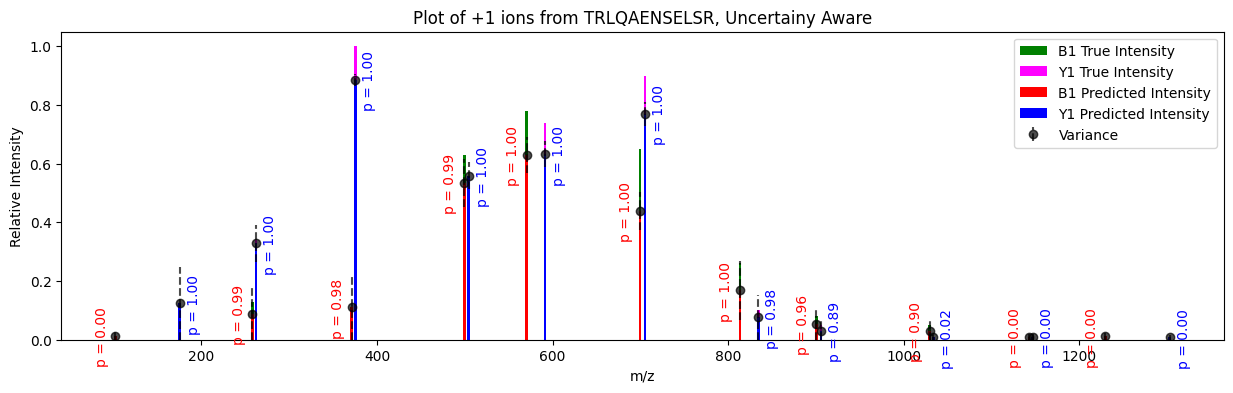

In [17]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Uncertainy Aware')

plt.bar(b1_mz, b1_ions_true, width=3, color='g', label='B1 True Intensity')
plt.bar(y1_mz, y1_ions_true, width=3, color='magenta', label='Y1 True Intensity')


plt.bar(b1_mz, b1_ions_mean, width=3, color='r', label='B1 Predicted Intensity')
eb_b = plt.errorbar(b1_mz, b1_ions_mean, yerr=[b1_ions_var_lower, b1_ions_var], color='black', fmt='o', alpha=0.7)
eb_b[-1][0].set_linestyle('--')
for xi, yi, presence, in zip(b1_mz, b1_ions_mean, b1_ions_presence):
    text = f"p = {presence:.2f}"
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
eb_y = plt.errorbar(y1_mz, y1_ions_mean, yerr=[y1_ions_var_lower, y1_ions_var], color='black', fmt='o', alpha=0.7, label='Variance')
eb_y[-1][0].set_linestyle('--')
for xi, yi, presence, in zip(y1_mz, y1_ions_mean, y1_ions_presence):
    text = f"p = {presence:.2f}"
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()

### Standard Prosit Model

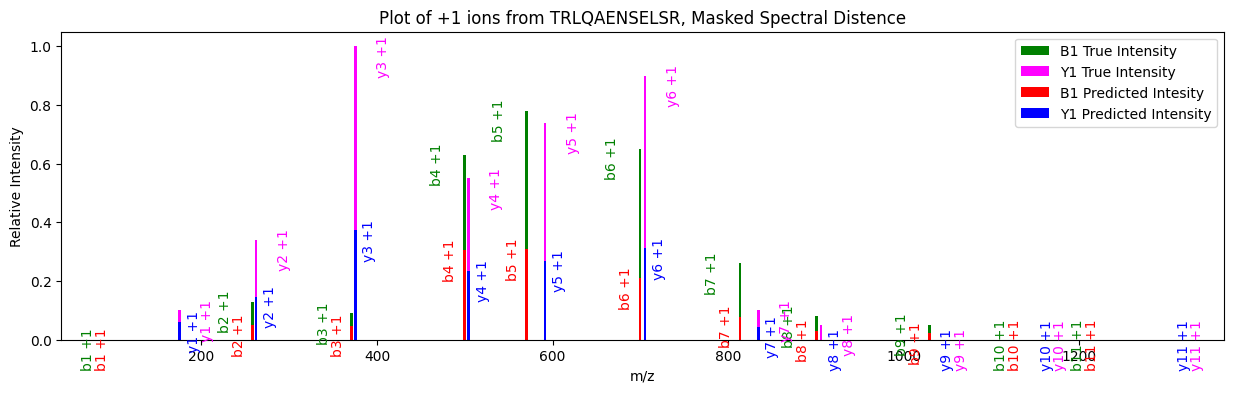

In [18]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Masked Spectral Distence')

plt.bar(b1_mz, b1_MSD_ions_true, width=3, color='g', label='B1 True Intensity')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-25, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_MSD_ions_true, width=3, color='magenta', label='Y1 True Intensity')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.bar(b1_mz, b1_MSD_ions_mean, width=3, color='r', label='B1 Predicted Intesity')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_MSD_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()
#plt.bar(y_mz, y_MSD_ions_mean, color='b')